# **Part-3**

In [ ]:
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

# **Step-1**

In [ ]:
dataset = load_dataset("ag_news")

train_data = dataset["train"]
test_data = dataset["test"]

print("Train size:", len(train_data))
print("Test size :", len(test_data))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Train size: 120000
Test size : 7600


In [ ]:
print(train_data[0])

{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


In [ ]:
train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)

print(train_df.head())

                                                text  label
0  Wall St. Bears Claw Back Into the Black (Reute...      2
1  Carlyle Looks Toward Commercial Aerospace (Reu...      2
2  Oil and Economy Cloud Stocks' Outlook (Reuters...      2
3  Iraq Halts Oil Exports from Main Southern Pipe...      2
4  Oil prices soar to all-time record, posing new...      2


In [ ]:
label_names = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Technology"
}

train_df["label_name"] = train_df["label"].map(label_names)
test_df["label_name"] = test_df["label"].map(label_names)

print(train_df[["text", "label", "label_name"]].head())

                                                text  label label_name
0  Wall St. Bears Claw Back Into the Black (Reute...      2   Business
1  Carlyle Looks Toward Commercial Aerospace (Reu...      2   Business
2  Oil and Economy Cloud Stocks' Outlook (Reuters...      2   Business
3  Iraq Halts Oil Exports from Main Southern Pipe...      2   Business
4  Oil prices soar to all-time record, posing new...      2   Business


In [ ]:
print("Training data shape :", train_df.shape)
print("Test data shape:", test_df.shape)

print("\nColumns:")
print(train_df.columns)

print("\nMissing values in training data:")
print(train_df.isnull().sum())

print("\nMissing values in test data:")
print(test_df.isnull().sum())

Training data shape : (120000, 3)
Test data shape: (7600, 3)

Columns:
Index(['text', 'label', 'label_name'], dtype='object')

Missing values in training data:
text          0
label         0
label_name    0
dtype: int64

Missing values in test data:
text          0
label         0
label_name    0
dtype: int64


In [ ]:
for i in range(5):
    print(f"Sample {i+1}")
    print("Label :", train_df.loc[i, "label_name"])
    print("Text  :", train_df.loc[i, "text"])

Sample 1
Label : Business
Text  : Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
Sample 2
Label : Business
Text  : Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.
Sample 3
Label : Business
Text  : Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums.
Sample 4
Label : Business
Text  : Iraq Halts Oil Exports from Main Southern Pipeline (Reuters) Reuters - Authorities have halted oil export\flows from the main pipeline in southern Iraq after\intelligence showed a rebel militia could strike\infrastructu

In [ ]:
class_counts = train_df["label_name"].value_counts()
print("Class distribution in training data:")
print(class_counts)

Class distribution in training data:
label_name
Business      30000
Technology    30000
Sports        30000
World         30000
Name: count, dtype: int64


In [ ]:
train_df["text_length"] = train_df["text"].apply(lambda x: len(x.split()))
test_df["text_length"] = test_df["text"].apply(lambda x: len(x.split()))

print("Text length statistics:")
print(train_df["text_length"].describe())

Text length statistics:
count    120000.000000
mean         37.847450
std          10.085245
min           8.000000
25%          32.000000
50%          37.000000
75%          43.000000
max         177.000000
Name: text_length, dtype: float64


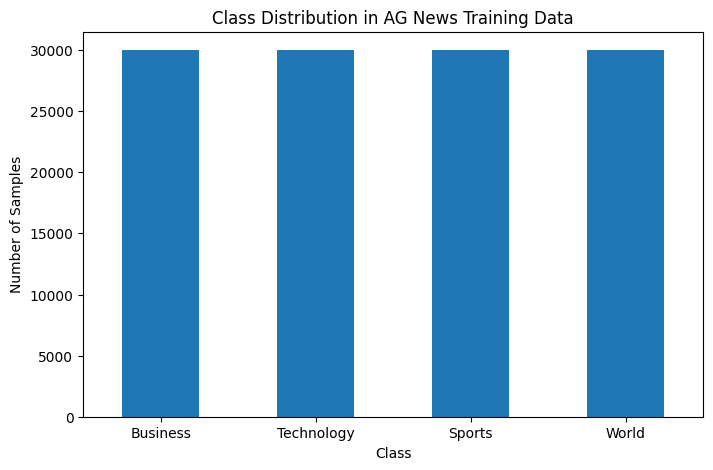

In [ ]:
plt.figure(figsize=(8, 5))
class_counts.plot(kind="bar")
plt.title("Class Distribution in AG News Training Data")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

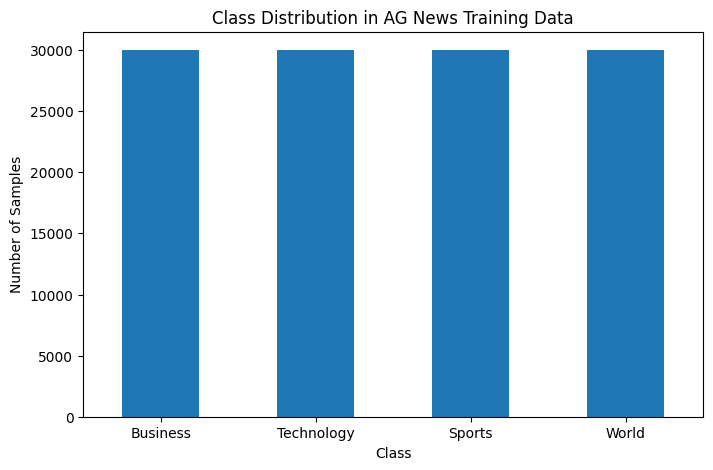

In [ ]:
plt.figure(figsize=(8, 5))
class_counts.plot(kind="bar")
plt.title("Class Distribution in AG News Training Data")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

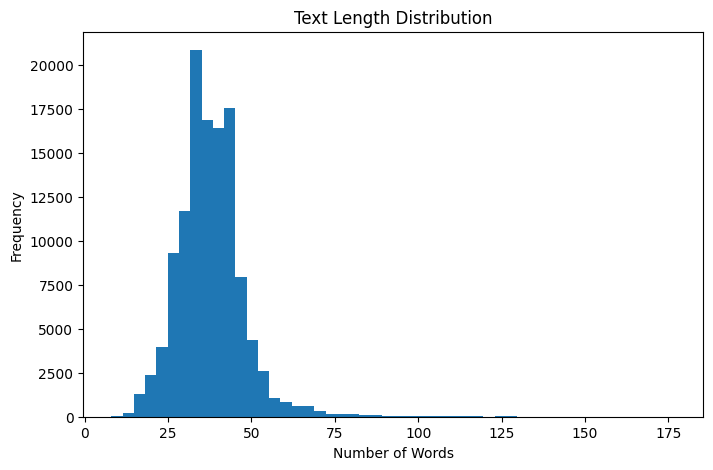

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(train_df["text_length"], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [ ]:
avg_length_per_class = train_df.groupby("label_name")["text_length"].mean().sort_values()

print("Average text length by class:")
print(avg_length_per_class)

Average text length by class:
label_name
Technology    37.191967
Business      37.538233
Sports        37.774733
World         38.884867
Name: text_length, dtype: float64


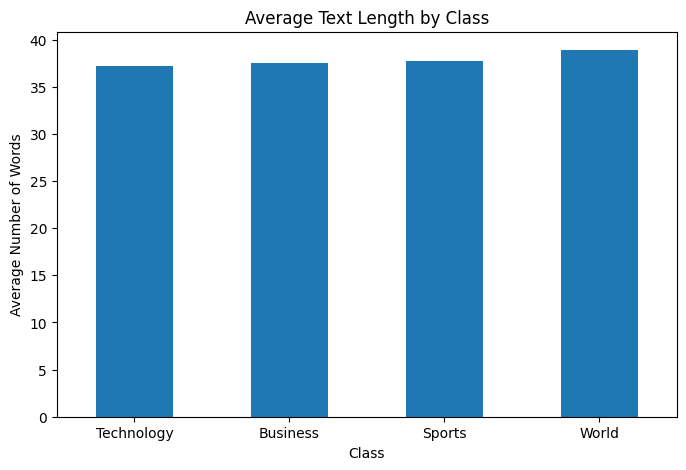

In [ ]:
plt.figure(figsize=(8, 5))
avg_length_per_class.plot(kind="bar")
plt.title("Average Text Length by Class")
plt.xlabel("Class")
plt.ylabel("Average Number of Words")
plt.xticks(rotation=0)
plt.show()

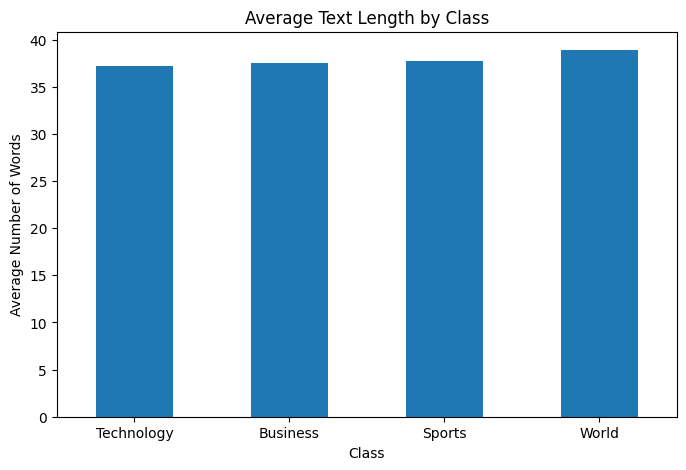

In [ ]:
plt.figure(figsize=(8, 5))
avg_length_per_class.plot(kind="bar")
plt.title("Average Text Length by Class")
plt.xlabel("Class")
plt.ylabel("Average Number of Words")
plt.xticks(rotation=0)
plt.show()

In [ ]:
import nltk
nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))
print("Number of stopwords:", len(stop_words))
print(list(stop_words)[:10])

Number of stopwords: 198
['more', 'mustn', 'through', 'at', 'once', "you'll", "couldn't", 'her', 'did', 'above']


# **2) Text Processing**

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [ ]:
#Tokenization
def preprocess_text(text):
    cleaned_text = clean_text(text)
    tokens = word_tokenize(cleaned_text)
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

In [ ]:
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt_tab', quiet=True)

for i in range(3):
    original_text = train_df.loc[i, "text"]
    cleaned = clean_text(original_text)
    tokens_list = preprocess_text(original_text)

    print(f"Sample {i+1}")
    print("Original Text :")
    print(original_text)
    print()

    print("Cleaned Text :")
    print(cleaned)
    print()

    print("Tokens :")
    print(tokens_list)
    print("-" * 100)

Sample 1
Original Text :
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

Cleaned Text :
wall st bears claw back into the black reuters reuters shortsellers wall streets dwindlingband of ultracynics are seeing green again

Tokens :
['wall', 'st', 'bears', 'claw', 'back', 'black', 'reuters', 'reuters', 'shortsellers', 'wall', 'streets', 'dwindlingband', 'ultracynics', 'seeing', 'green']
----------------------------------------------------------------------------------------------------
Sample 2
Original Text :
Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.

Cleaned Text :
carlyle looks toward commercial aerospace reuters reuters private investment firm carlyle groupwhich has 

In [ ]:
train_df["tokens"] = train_df["text"].apply(preprocess_text)
test_df["tokens"] = test_df["text"].apply(preprocess_text)

train_df["token_count"] = train_df["tokens"].apply(len)
test_df["token_count"] = test_df["tokens"].apply(len)

print("Token count statistics")
print(train_df["token_count"].describe())

Token count statistics
count    120000.000000
mean         24.758508
std           6.345436
min           6.000000
25%          21.000000
50%          24.000000
75%          28.000000
max         100.000000
Name: token_count, dtype: float64


In [ ]:
from collections import Counter

all_tokens = []

for tokens in train_df["tokens"]:
    all_tokens.extend(tokens)

token_counts = Counter(all_tokens)

print("Total unique tokens in training data:", len(token_counts))
print("Most common 10 tokens:")
print(token_counts.most_common(10))

Total unique tokens in training data: 90490
Most common 10 tokens:
[('new', 21223), ('said', 19995), ('us', 19742), ('reuters', 17243), ('ap', 16148), ('first', 9040), ('two', 8925), ('world', 7473), ('monday', 7448), ('wednesday', 7317)]


In [ ]:
#Volcabulary Size
vocab = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word, count in token_counts.items():
    vocab[word] = len(vocab)

print("Final vocabulary size:", len(vocab))

Final vocabulary size: 90492


In [ ]:
index_to_word = {index: word for word, index in vocab.items()}

print("vocabulary items:")
for i, (word, index) in enumerate(vocab.items()):
    if i == 10:
        break
    print(word, "->", index)

vocabulary items:
<PAD> -> 0
<UNK> -> 1
wall -> 2
st -> 3
bears -> 4
claw -> 5
back -> 6
black -> 7
reuters -> 8
shortsellers -> 9


In [ ]:
#Converting to indices
def tokens_to_indices(tokens, vocab):
    indices = []
    for token in tokens:
        if token in vocab:
            indices.append(vocab[token])
        else:
            indices.append(vocab["<UNK>"])
    return indices

In [ ]:
train_df["input_ids"] = train_df["tokens"].apply(lambda x: tokens_to_indices(x, vocab))
test_df["input_ids"] = test_df["tokens"].apply(lambda x: tokens_to_indices(x, vocab))

In [ ]:
sample_index = 0

print("Original text:")
print(train_df.loc[sample_index, "text"])
print()
print("Tokens:")
print(train_df.loc[sample_index, "tokens"])
print()
print("Input IDs:")
print(train_df.loc[sample_index, "input_ids"])

Original text:
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

Tokens:
['wall', 'st', 'bears', 'claw', 'back', 'black', 'reuters', 'reuters', 'shortsellers', 'wall', 'streets', 'dwindlingband', 'ultracynics', 'seeing', 'green']

Input IDs:
[2, 3, 4, 5, 6, 7, 8, 8, 9, 2, 10, 11, 12, 13, 14]


In [ ]:
train_df["sequence_length"] = train_df["input_ids"].apply(len)
test_df["sequence_length"] = test_df["input_ids"].apply(len)

print("Sequence length statistics:")
print(train_df["sequence_length"].describe())

Sequence length statistics:
count    120000.000000
mean         24.758508
std           6.345436
min           6.000000
25%          21.000000
50%          24.000000
75%          28.000000
max         100.000000
Name: sequence_length, dtype: float64


 Padding, train-validation split, and DataLoader creation

In [ ]:
max_length = 100
print("Maximum sequence length:", max_length)

Maximum sequence length: 100


In [ ]:
def pad_sequence(sequence, max_length, pad_value=0):
    if len(sequence) < max_length:
        sequence = sequence + [pad_value] * (max_length - len(sequence))
    else:
        sequence = sequence[:max_length]
    return sequence

In [ ]:
train_df["padded_input_ids"] = train_df["input_ids"].apply(lambda x: pad_sequence(x, max_length))
test_df["padded_input_ids"] = test_df["input_ids"].apply(lambda x: pad_sequence(x, max_length))

In [ ]:
def create_attention_mask(sequence, pad_value=0):
    return [0 if token == pad_value else 1 for token in sequence]

train_df["attention_mask"] = train_df["padded_input_ids"].apply(create_attention_mask)
test_df["attention_mask"] = test_df["padded_input_ids"].apply(create_attention_mask)

In [ ]:
sample_index = 0

print("Tokens:")
print(train_df.loc[sample_index, "tokens"])
print()

print("Padded input ids:")
print(train_df.loc[sample_index, "padded_input_ids"])
print()

print("Attention mask:")
print(train_df.loc[sample_index, "attention_mask"])
print()

print("Label:")
print(train_df.loc[sample_index, "label"])

Tokens:
['wall', 'st', 'bears', 'claw', 'back', 'black', 'reuters', 'reuters', 'shortsellers', 'wall', 'streets', 'dwindlingband', 'ultracynics', 'seeing', 'green']

Padded input ids:
[2, 3, 4, 5, 6, 7, 8, 8, 9, 2, 10, 11, 12, 13, 14, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Attention mask:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Label:
2


In [ ]:
from sklearn.model_selection import train_test_split

train_inputs, val_inputs, train_masks, val_masks, train_labels, val_labels = train_test_split(
    train_df["padded_input_ids"].tolist(),
    train_df["attention_mask"].tolist(),
    train_df["label"].tolist(),
    test_size=0.1,
    random_state=42,
    stratify=train_df["label"]
)

print("Training samples   :", len(train_inputs))
print("Validation samples :", len(val_inputs))
print("Test samples       :", len(test_df))

Training samples   : 108000
Validation samples : 12000
Test samples       : 7600


In [ ]:
import torch

train_inputs = torch.tensor(train_inputs, dtype=torch.long)
val_inputs = torch.tensor(val_inputs, dtype=torch.long)
test_inputs = torch.tensor(test_df["padded_input_ids"].tolist(), dtype=torch.long)

train_masks = torch.tensor(train_masks, dtype=torch.long)
val_masks = torch.tensor(val_masks, dtype=torch.long)
test_masks = torch.tensor(test_df["attention_mask"].tolist(), dtype=torch.long)

train_labels = torch.tensor(train_labels, dtype=torch.long)
val_labels = torch.tensor(val_labels, dtype=torch.long)
test_labels = torch.tensor(test_df["label"].tolist(), dtype=torch.long)

In [ ]:
from torch.utils.data import Dataset, DataLoader

class AGNewsDataset(Dataset):
    def __init__(self, input_ids, attention_masks, labels):
        self.input_ids = input_ids
        self.attention_masks = attention_masks
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return {
            "input_ids": self.input_ids[index],
            "attention_mask": self.attention_masks[index],
            "label": self.labels[index]
        }

train_dataset = AGNewsDataset(train_inputs, train_masks, train_labels)
val_dataset = AGNewsDataset(val_inputs, val_masks, val_labels)
test_dataset = AGNewsDataset(test_inputs, test_masks, test_labels)

In [ ]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Number of training batches  :", len(train_loader))
print("Number of validation batches:", len(val_loader))
print("Number of test batches      :", len(test_loader))

Number of training batches  : 1688
Number of validation batches: 188
Number of test batches      : 119


In [ ]:
batch = next(iter(train_loader))

print("Input ids shape     :", batch["input_ids"].shape)
print("Attention mask shape:", batch["attention_mask"].shape)
print("Labels shape        :", batch["label"].shape)

Input ids shape     : torch.Size([64, 100])
Attention mask shape: torch.Size([64, 100])
Labels shape        : torch.Size([64])


In [ ]:
import math
import torch.nn as nn

# **Step-2 Model Construction**

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, max_length):
        super().__init__()

        positional_encoding = torch.zeros(max_length, embed_dim)

        positions = torch.arange(0, max_length, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, embed_dim, 2).float() * (-math.log(10000.0) / embed_dim))

        positional_encoding[:, 0::2] = torch.sin(positions * div_term)
        positional_encoding[:, 1::2] = torch.cos(positions * div_term)

        positional_encoding = positional_encoding.unsqueeze(0)   # shape: (1, max_length, embed_dim)

        self.register_buffer("positional_encoding", positional_encoding)

    def forward(self, x):
        sequence_length = x.size(1)
        x = x + self.positional_encoding[:, :sequence_length, :]
        return x

In [ ]:
embed_dim = 128

positional_encoding_layer = PositionalEncoding(embed_dim=embed_dim, max_length=max_length)

dummy_embeddings = torch.zeros(2, max_length, embed_dim)
output = positional_encoding_layer(dummy_embeddings)

print("Input shape :", dummy_embeddings.shape)
print("Output shape:", output.shape)

Input shape : torch.Size([2, 100, 128])
Output shape: torch.Size([2, 100, 128])


In [ ]:
import torch.nn as nn

In [ ]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, ff_dim, num_layers, max_length, num_classes, dropout=0.1):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.positional_encoding = PositionalEncoding(embed_dim, max_length)
        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=num_layers
        )

        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, input_ids, attention_mask):
        x = self.embedding(input_ids)
        x = self.positional_encoding(x)
        x = self.dropout(x)

        padding_mask = attention_mask == 0

        encoder_output = self.transformer_encoder(
            x,
            src_key_padding_mask=padding_mask
        )

        attention_mask = attention_mask.unsqueeze(-1)
        masked_output = encoder_output * attention_mask

        summed_output = masked_output.sum(dim=1)
        valid_token_count = attention_mask.sum(dim=1)

        pooled_output = summed_output / valid_token_count
        logits = self.classifier(pooled_output)

        return logits

In [ ]:
model = TransformerClassifier(
    vocab_size=len(vocab),
    embed_dim=128,
    num_heads=4,
    ff_dim=256,
    num_layers=2,
    max_length=max_length,
    num_classes=4,
    dropout=0.1
)

batch = next(iter(train_loader))

logits = model(batch["input_ids"], batch["attention_mask"])

print("Logits shape:", logits.shape)

Logits shape: torch.Size([64, 4])


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = model.to(device)

Using device: cuda


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

In [ ]:
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=2,
    gamma=0.5)

# **Step 3: Training the Transformer**

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [ ]:
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    model.train()

    total_loss = 0
    all_predictions = []
    all_labels = []

    for batch in data_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        predictions = torch.argmax(logits, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(all_labels, all_predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return avg_loss, accuracy, precision, recall, f1

In [ ]:
def evaluate_model(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

            total_loss += loss.item()

            predictions = torch.argmax(logits, dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(all_labels, all_predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return avg_loss, accuracy, precision, recall, f1, all_labels, all_predictions

# **Training the Transformer**

In [ ]:
num_epochs = 8

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
val_f1_scores = []

best_val_f1 = 0

for epoch in range(num_epochs):
    train_loss, train_acc, train_prec, train_rec, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, device)

    val_loss, val_acc, val_prec, val_rec, val_f1, _, _ = evaluate_model(
        model, val_loader, criterion, device
    )

    scheduler.step()

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    val_f1_scores.append(val_f1)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f} | Train F1: {train_f1:.4f}")
    print(f"Val Loss  : {val_loss:.4f} | Val Accuracy  : {val_acc:.4f} | Val F1  : {val_f1:.4f}")
    print("-" * 60)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), "best_transformer_model.pt")
        print("Best model saved.\n")

Epoch 1/8
Train Loss: 0.4850 | Train Accuracy: 0.8209 | Train F1: 0.8205
Val Loss  : 0.3485 | Val Accuracy  : 0.8792 | Val F1  : 0.8796
------------------------------------------------------------
Best model saved.

Epoch 2/8
Train Loss: 0.3063 | Train Accuracy: 0.8951 | Train F1: 0.8950
Val Loss  : 0.2717 | Val Accuracy  : 0.9074 | Val F1  : 0.9071
------------------------------------------------------------
Best model saved.

Epoch 3/8
Train Loss: 0.2326 | Train Accuracy: 0.9201 | Train F1: 0.9200
Val Loss  : 0.2530 | Val Accuracy  : 0.9173 | Val F1  : 0.9173
------------------------------------------------------------
Best model saved.

Epoch 4/8
Train Loss: 0.2061 | Train Accuracy: 0.9293 | Train F1: 0.9292
Val Loss  : 0.2577 | Val Accuracy  : 0.9150 | Val F1  : 0.9152
------------------------------------------------------------
Epoch 5/8
Train Loss: 0.1673 | Train Accuracy: 0.9430 | Train F1: 0.9430
Val Loss  : 0.2466 | Val Accuracy  : 0.9243 | Val F1  : 0.9240
-------------------

In [ ]:

best_model = TransformerClassifier(
    vocab_size=len(vocab),
    embed_dim=128,
    num_heads=4,
    ff_dim=256,
    num_layers=2,
    max_length=max_length,
    num_classes=4,
    dropout=0.1
)

best_model.load_state_dict(torch.load("best_transformer_model.pt", map_location=device))
best_model = best_model.to(device)

In [ ]:

test_loss, test_acc, test_prec, test_rec, test_f1, test_labels_list, test_predictions_list = evaluate_model(
    best_model, test_loader, criterion, device
)

print("Test Loss     :", round(test_loss, 4))
print("Test Accuracy :", round(test_acc, 4))
print("Test Precision:", round(test_prec, 4))
print("Test Recall   :", round(test_rec, 4))
print("Test F1 Score :", round(test_f1, 4))

Test Loss     : 0.2599
Test Accuracy : 0.9245
Test Precision: 0.9244
Test Recall   : 0.9245
Test F1 Score : 0.9243


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    test_labels_list,
    test_predictions_list,
    target_names=["World", "Sports", "Business", "Technology"],
    digits=4
))

              precision    recall  f1-score   support

       World     0.9382    0.9195    0.9288      1900
      Sports     0.9604    0.9832    0.9717      1900
    Business     0.9079    0.8816    0.8945      1900
  Technology     0.8912    0.9137    0.9023      1900

    accuracy                         0.9245      7600
   macro avg     0.9244    0.9245    0.9243      7600
weighted avg     0.9244    0.9245    0.9243      7600



In [ ]:
print("Final Training Loss     :", round(train_losses[-1], 4))
print("Final Training Accuracy :", round(train_accuracies[-1], 4))

print("Final Validation Loss   :", round(val_losses[-1], 4))
print("Final Validation Accuracy:", round(val_accuracies[-1], 4))

print("Final Testing Loss      :", round(test_loss, 4))
print("Final Testing Accuracy  :", round(test_acc, 4))

Final Training Loss     : 0.1227
Final Training Accuracy : 0.9575
Final Validation Loss   : 0.2747
Final Validation Accuracy: 0.9257
Final Testing Loss      : 0.2599
Final Testing Accuracy  : 0.9245


# **Step 4: Evaluation and Optimization**

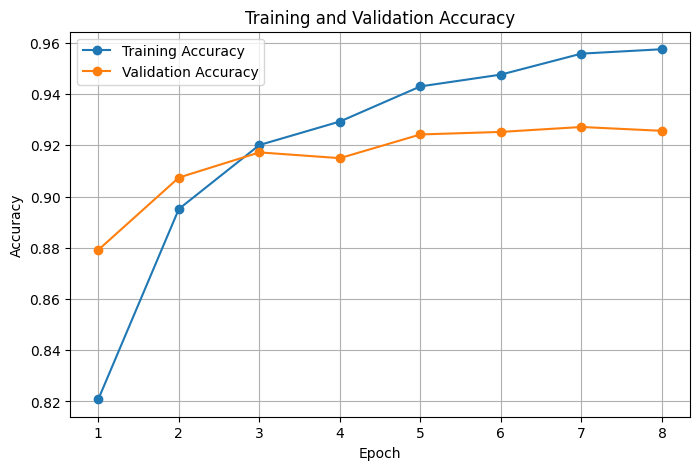

In [ ]:
epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_accuracies, marker='o', label="Training Accuracy")
plt.plot(epochs_range, val_accuracies, marker='o', label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

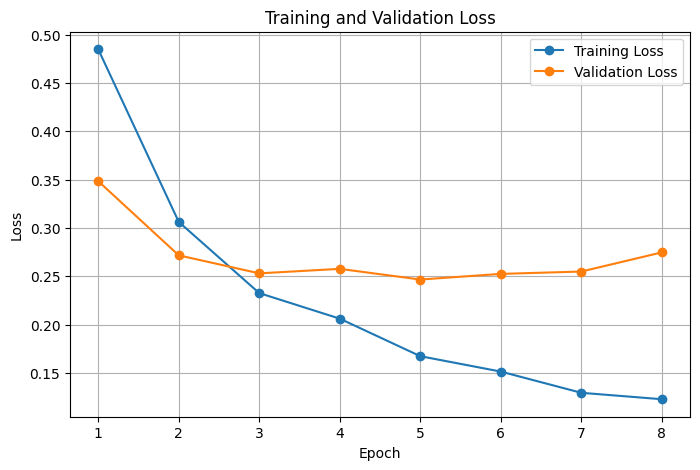

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, marker='o', label="Training Loss")
plt.plot(epochs_range, val_losses, marker='o', label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

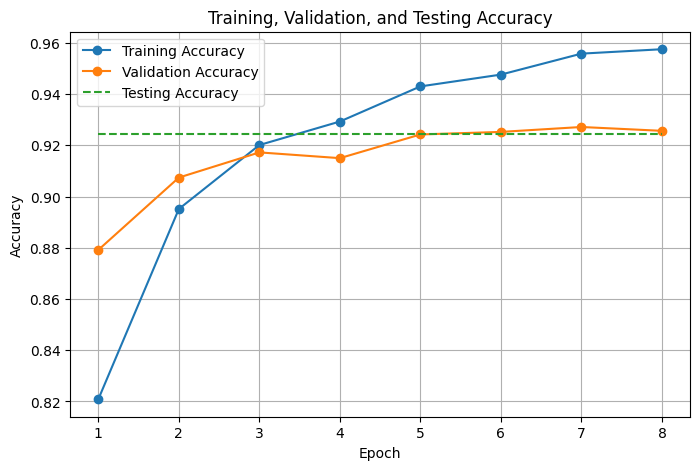

In [ ]:
test_accuracies = [test_acc] * num_epochs
test_losses = [test_loss] * num_epochs

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_accuracies, marker='o', label="Training Accuracy")
plt.plot(epochs_range, val_accuracies, marker='o', label="Validation Accuracy")
plt.plot(epochs_range, test_accuracies, linestyle='--', label="Testing Accuracy")
plt.title("Training, Validation, and Testing Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

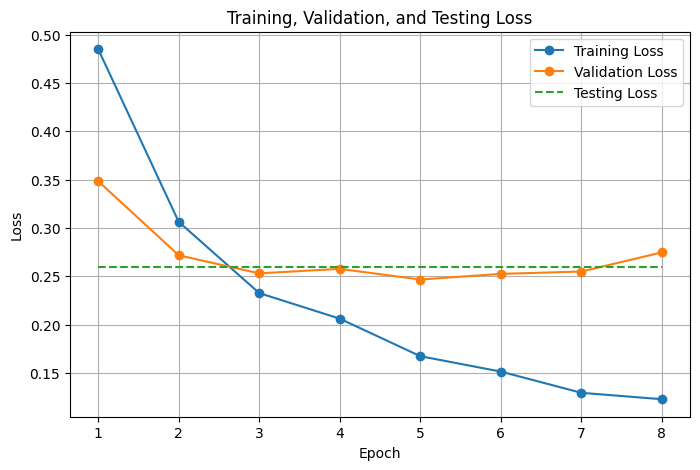

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, marker='o', label="Training Loss")
plt.plot(epochs_range, val_losses, marker='o', label="Validation Loss")
plt.plot(epochs_range, test_losses, linestyle='--', label="Testing Loss")
plt.title("Training, Validation, and Testing Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

<Figure size 800x600 with 0 Axes>

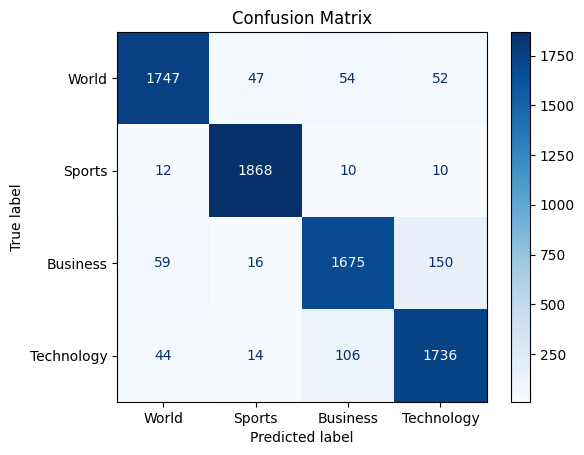

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(test_labels_list, test_predictions_list)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["World", "Sports", "Business", "Technology"]
)

plt.figure(figsize=(8, 6))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import torch.nn.functional as F

best_model.eval()

all_probabilities = []
all_true_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        logits = best_model(input_ids, attention_mask)
        probabilities = F.softmax(logits, dim=1)

        all_probabilities.extend(probabilities.cpu().numpy())
        all_true_labels.extend(labels.cpu().numpy())

all_probabilities = np.array(all_probabilities)
all_true_labels = np.array(all_true_labels)

In [ ]:
num_classes = 4
true_labels_binarized = label_binarize(all_true_labels, classes=[0, 1, 2, 3])

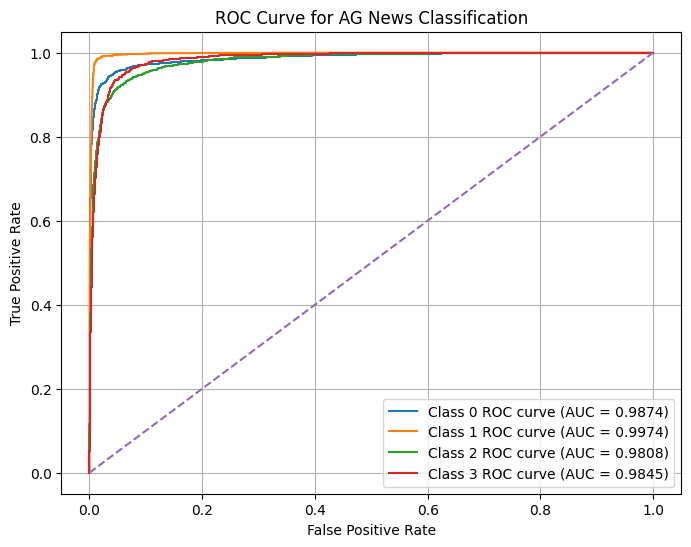

In [ ]:
plt.figure(figsize=(8, 6))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(true_labels_binarized[:, i], all_probabilities[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} ROC curve (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for AG News Classification")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def run_experiment(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=3, scheduler=None):
    history = {
        "train_loss": [],
        "train_accuracy": [],
        "train_f1": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_f1": []
    }

    best_val_f1 = 0
    best_epoch_result = None

    for epoch in range(num_epochs):
        train_loss, train_acc, train_prec, train_rec, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        val_loss, val_acc, val_prec, val_rec, val_f1, _, _ = evaluate_model(
            model, val_loader, criterion, device
        )

        if scheduler is not None:
            scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_acc)
        history["train_f1"].append(train_f1)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)
        history["val_f1"].append(val_f1)

        print(f"Epoch {epoch + 1}/{num_epochs}")
        print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f} | Train F1: {train_f1:.4f}")
        print(f"Val Loss  : {val_loss:.4f} | Val Accuracy  : {val_acc:.4f} | Val F1  : {val_f1:.4f}")


        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch_result = {
                "best_val_loss": val_loss,
                "best_val_accuracy": val_acc,
                "best_val_f1": val_f1
            }

    return history, best_epoch_result

In [ ]:
experiment_results = []

In [ ]:
dropout_values = [0.1, 0.2]

for dropout_value in dropout_values:
    print(f"\n Dropout = {dropout_value}")

    model = TransformerClassifier(
        vocab_size=len(vocab),
        embed_dim=128,
        num_heads=4,
        ff_dim=256,
        num_layers=2,
        max_length=max_length,
        num_classes=4,
        dropout=dropout_value
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-3,
        weight_decay=1e-5
    )

    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=2,
        gamma=0.5
    )

    history, best_result = run_experiment(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_epochs=3,
        scheduler=scheduler
    )

    experiment_results.append({
        "technique": "Dropout",
        "setting": f"dropout={dropout_value}",
        "best_val_loss": best_result["best_val_loss"],
        "best_val_accuracy": best_result["best_val_accuracy"],
        "best_val_f1": best_result["best_val_f1"]
    })


 Dropout = 0.1
Epoch 1/3
Train Loss: 0.4805 | Train Accuracy: 0.8243 | Train F1: 0.8240
Val Loss  : 0.3422 | Val Accuracy  : 0.8861 | Val F1  : 0.8852
Epoch 2/3
Train Loss: 0.3074 | Train Accuracy: 0.8941 | Train F1: 0.8939
Val Loss  : 0.2783 | Val Accuracy  : 0.9062 | Val F1  : 0.9059
Epoch 3/3
Train Loss: 0.2391 | Train Accuracy: 0.9185 | Train F1: 0.9184
Val Loss  : 0.2674 | Val Accuracy  : 0.9123 | Val F1  : 0.9124

 Dropout = 0.2
Epoch 1/3
Train Loss: 0.5319 | Train Accuracy: 0.8018 | Train F1: 0.8013
Val Loss  : 0.3239 | Val Accuracy  : 0.8898 | Val F1  : 0.8899
Epoch 2/3
Train Loss: 0.3341 | Train Accuracy: 0.8840 | Train F1: 0.8838
Val Loss  : 0.3007 | Val Accuracy  : 0.9013 | Val F1  : 0.9008
Epoch 3/3
Train Loss: 0.2606 | Train Accuracy: 0.9106 | Train F1: 0.9105
Val Loss  : 0.2571 | Val Accuracy  : 0.9148 | Val F1  : 0.9147


In [ ]:
weight_decay_values = [0.0, 1e-5]

for weight_decay_value in weight_decay_values:
    print(f"\nweight_decay = {weight_decay_value}")

    model = TransformerClassifier(
        vocab_size=len(vocab),
        embed_dim=128,
        num_heads=4,
        ff_dim=256,
        num_layers=2,
        max_length=max_length,
        num_classes=4,
        dropout=0.1
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-3,
        weight_decay=weight_decay_value
    )

    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=2,
        gamma=0.5
    )

    history, best_result = run_experiment(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_epochs=3,
        scheduler=scheduler
    )

    experiment_results.append({
        "technique": "L2 Regularization",
        "setting": f"weight_decay={weight_decay_value}",
        "best_val_loss": best_result["best_val_loss"],
        "best_val_accuracy": best_result["best_val_accuracy"],
        "best_val_f1": best_result["best_val_f1"]
    })


weight_decay = 0.0
Epoch 1/3
Train Loss: 0.4878 | Train Accuracy: 0.8207 | Train F1: 0.8203
Val Loss  : 0.3381 | Val Accuracy  : 0.8826 | Val F1  : 0.8817
Epoch 2/3
Train Loss: 0.2943 | Train Accuracy: 0.8987 | Train F1: 0.8985
Val Loss  : 0.2781 | Val Accuracy  : 0.9068 | Val F1  : 0.9068
Epoch 3/3
Train Loss: 0.2171 | Train Accuracy: 0.9256 | Train F1: 0.9255
Val Loss  : 0.2657 | Val Accuracy  : 0.9153 | Val F1  : 0.9150

weight_decay = 1e-05
Epoch 1/3
Train Loss: 0.4842 | Train Accuracy: 0.8217 | Train F1: 0.8213
Val Loss  : 0.3231 | Val Accuracy  : 0.8902 | Val F1  : 0.8901
Epoch 2/3
Train Loss: 0.3082 | Train Accuracy: 0.8940 | Train F1: 0.8939
Val Loss  : 0.2893 | Val Accuracy  : 0.9019 | Val F1  : 0.9022
Epoch 3/3
Train Loss: 0.2341 | Train Accuracy: 0.9193 | Train F1: 0.9192
Val Loss  : 0.2545 | Val Accuracy  : 0.9170 | Val F1  : 0.9169


In [ ]:
learning_rates = [1e-3, 5e-4]

for learning_rate in learning_rates:
    print(f"\n  lr = {learning_rate}")

    model = TransformerClassifier(
        vocab_size=len(vocab),
        embed_dim=128,
        num_heads=4,
        ff_dim=256,
        num_layers=2,
        max_length=max_length,
        num_classes=4,
        dropout=0.1
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=1e-5
    )

    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=2,
        gamma=0.5
    )

    history, best_result = run_experiment(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_epochs=3,
        scheduler=scheduler
    )

    experiment_results.append({
        "technique": "Learning Rate",
        "setting": f"lr={learning_rate}",
        "best_val_loss": best_result["best_val_loss"],
        "best_val_accuracy": best_result["best_val_accuracy"],
        "best_val_f1": best_result["best_val_f1"]
    })


  lr = 0.001
Epoch 1/3
Train Loss: 0.4899 | Train Accuracy: 0.8190 | Train F1: 0.8187
Val Loss  : 0.3186 | Val Accuracy  : 0.8922 | Val F1  : 0.8918
Epoch 2/3
Train Loss: 0.3064 | Train Accuracy: 0.8940 | Train F1: 0.8939
Val Loss  : 0.2831 | Val Accuracy  : 0.9025 | Val F1  : 0.9021
Epoch 3/3
Train Loss: 0.2359 | Train Accuracy: 0.9179 | Train F1: 0.9178
Val Loss  : 0.2508 | Val Accuracy  : 0.9190 | Val F1  : 0.9189

  lr = 0.0005
Epoch 1/3
Train Loss: 0.5363 | Train Accuracy: 0.7988 | Train F1: 0.7983
Val Loss  : 0.3548 | Val Accuracy  : 0.8780 | Val F1  : 0.8770
Epoch 2/3
Train Loss: 0.3339 | Train Accuracy: 0.8823 | Train F1: 0.8821
Val Loss  : 0.3134 | Val Accuracy  : 0.8920 | Val F1  : 0.8923
Epoch 3/3
Train Loss: 0.2674 | Train Accuracy: 0.9073 | Train F1: 0.9072
Val Loss  : 0.2899 | Val Accuracy  : 0.9042 | Val F1  : 0.9035


In [ ]:
results_df = pd.DataFrame(experiment_results)
results_df = results_df.sort_values(by="best_val_f1", ascending=False).reset_index(drop=True)

print(results_df)

           technique             setting  best_val_loss  best_val_accuracy  \
0      Learning Rate            lr=0.001       0.250782           0.919000   
1  L2 Regularization  weight_decay=1e-05       0.254524           0.917000   
2  L2 Regularization    weight_decay=0.0       0.265732           0.915333   
3            Dropout         dropout=0.2       0.257056           0.914833   
4            Dropout         dropout=0.1       0.267377           0.912333   
5      Learning Rate           lr=0.0005       0.289918           0.904167   

   best_val_f1  
0     0.918924  
1     0.916886  
2     0.915034  
3     0.914675  
4     0.912375  
5     0.903518  


In [ ]:
best_by_technique = results_df.groupby("technique", as_index=False).first()
print(best_by_technique)

           technique             setting  best_val_loss  best_val_accuracy  \
0            Dropout         dropout=0.2       0.257056           0.914833   
1  L2 Regularization  weight_decay=1e-05       0.254524           0.917000   
2      Learning Rate            lr=0.001       0.250782           0.919000   

   best_val_f1  
0     0.914675  
1     0.916886  
2     0.918924  


**Learning Rate Tuning:** The learning rate had the most impact on the model's performance. A learning rate of 0.001 achieved the highest validation F1-score of 0.9189.

**L2 Regularization :** Applying a small amount of L2 regularization helped to prevent the model's weights from becoming too large.

**Dropout :** Dropout is a regularization technique that randomly sets a fraction of neurons to zero during training, forcing the network to learn more robust features. Increasing the dropout rate from 0.1 to 0.2 improved the validation F1-score from 0.9124 to 0.9147.

In [ ]:
final_model = TransformerClassifier(
    vocab_size=len(vocab),
    embed_dim=128,
    num_heads=4,
    ff_dim=256,
    num_layers=2,
    max_length=max_length,
    num_classes=4,
    dropout=0.1
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    final_model.parameters(),
    lr=5e-4,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=2,
    gamma=0.5
)

In [ ]:
num_epochs = 8

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
val_f1_scores = []

best_val_f1 = 0

for epoch in range(num_epochs):
    train_loss, train_acc, train_prec, train_rec, train_f1 = train_one_epoch(
        final_model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc, val_prec, val_rec, val_f1, _, _ = evaluate_model(
        final_model, val_loader, criterion, device
    )

    scheduler.step()

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    val_f1_scores.append(val_f1)

    print(f"Epoch {epoch + 1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f} | Train F1: {train_f1:.4f}")
    print(f"Val Loss  : {val_loss:.4f} | Val Accuracy  : {val_acc:.4f} | Val F1  : {val_f1:.4f}")
    print("-" * 60)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(final_model.state_dict(), "best_transformer_model.pt")
        print("Best model saved.\n")

Epoch 1/8
Train Loss: 0.5365 | Train Accuracy: 0.7994 | Train F1: 0.7988
Val Loss  : 0.3630 | Val Accuracy  : 0.8765 | Val F1  : 0.8761
------------------------------------------------------------
Best model saved.

Epoch 2/8
Train Loss: 0.3343 | Train Accuracy: 0.8824 | Train F1: 0.8822
Val Loss  : 0.3060 | Val Accuracy  : 0.8978 | Val F1  : 0.8977
------------------------------------------------------------
Best model saved.

Epoch 3/8
Train Loss: 0.2672 | Train Accuracy: 0.9068 | Train F1: 0.9067
Val Loss  : 0.2790 | Val Accuracy  : 0.9094 | Val F1  : 0.9091
------------------------------------------------------------
Best model saved.

Epoch 4/8
Train Loss: 0.2431 | Train Accuracy: 0.9150 | Train F1: 0.9150
Val Loss  : 0.2740 | Val Accuracy  : 0.9089 | Val F1  : 0.9089
------------------------------------------------------------
Epoch 5/8
Train Loss: 0.2129 | Train Accuracy: 0.9255 | Train F1: 0.9254
Val Loss  : 0.2649 | Val Accuracy  : 0.9145 | Val F1  : 0.9142
-------------------

In [ ]:
best_model = TransformerClassifier(
    vocab_size=len(vocab),
    embed_dim=128,
    num_heads=4,
    ff_dim=256,
    num_layers=2,
    max_length=max_length,
    num_classes=4,
    dropout=0.1
).to(device)

best_model.load_state_dict(torch.load("best_transformer_model.pt", map_location=device))
best_model.eval()


TransformerClassifier(
  (embedding): Embedding(90492, 128)
  (positional_encoding): PositionalEncoding()
  (dropout): Dropout(p=0.1, inplace=False)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classifier): Linear(in_features=128, out_features=4, bias=True)
)

In [ ]:
test_loss, test_acc, test_prec, test_rec, test_f1, test_labels_list, test_predictions_list = evaluate_model(
    best_model,
    test_loader,
    criterion,
    device
)

print("Test Loss      :", round(test_loss, 4))
print("Test Accuracy  :", round(test_acc, 4))
print("Test Precision :", round(test_prec, 4))
print("Test Recall    :", round(test_rec, 4))
print("Test F1 Score  :", round(test_f1, 4))

Test Loss      : 0.2702
Test Accuracy  : 0.9136
Test Precision : 0.9138
Test Recall    : 0.9136
Test F1 Score  : 0.9135


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    test_labels_list,
    test_predictions_list,
    target_names=["World", "Sports", "Business", "Technology"],
    digits=4
))

              precision    recall  f1-score   support

       World     0.9401    0.9089    0.9243      1900
      Sports     0.9542    0.9763    0.9651      1900
    Business     0.8908    0.8674    0.8789      1900
  Technology     0.8700    0.9016    0.8855      1900

    accuracy                         0.9136      7600
   macro avg     0.9138    0.9136    0.9135      7600
weighted avg     0.9138    0.9136    0.9135      7600



In [ ]:
print("Final Training Loss      :", round(train_losses[-1], 4))
print("Final Training Accuracy  :", round(train_accuracies[-1], 4))
print("Final Validation Loss    :", round(val_losses[-1], 4))
print("Final Validation Accuracy:", round(val_accuracies[-1], 4))
print("Final Testing Loss       :", round(test_loss, 4))
print("Final Testing Accuracy   :", round(test_acc, 4))

Final Training Loss      : 0.1774
Final Training Accuracy  : 0.9375
Final Validation Loss    : 0.2689
Final Validation Accuracy: 0.9167
Final Testing Loss       : 0.2702
Final Testing Accuracy   : 0.9136


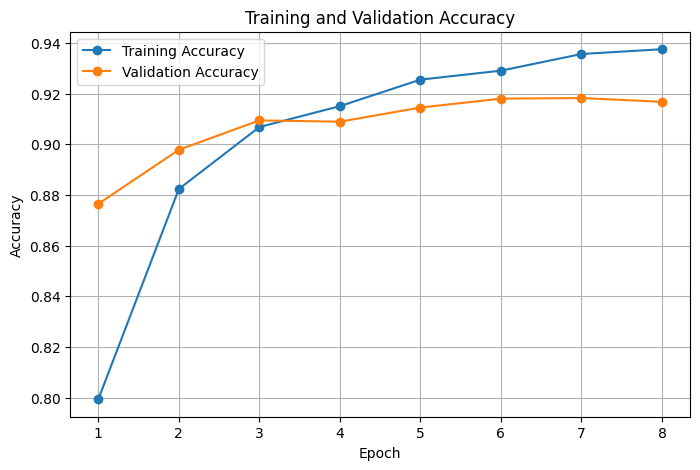

In [ ]:
epochs_range = range(1, len(train_accuracies) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_accuracies, marker='o', label="Training Accuracy")
plt.plot(epochs_range, val_accuracies, marker='o', label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

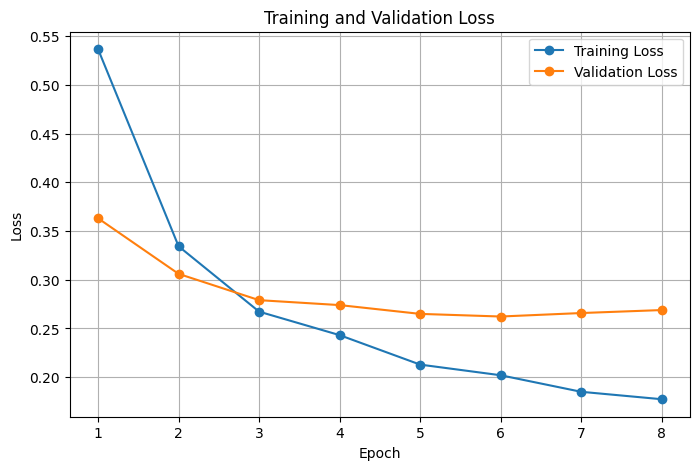

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, marker='o', label="Training Loss")
plt.plot(epochs_range, val_losses, marker='o', label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

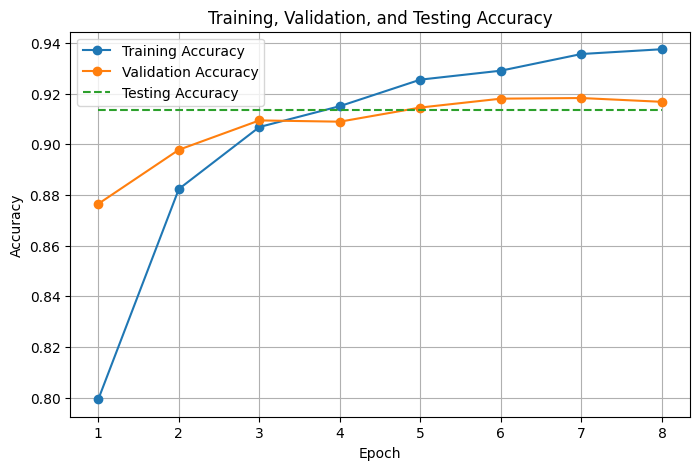

In [ ]:
test_accuracies = [test_acc] * len(train_accuracies)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_accuracies, marker='o', label="Training Accuracy")
plt.plot(epochs_range, val_accuracies, marker='o', label="Validation Accuracy")
plt.plot(epochs_range, test_accuracies, linestyle='--', label="Testing Accuracy")
plt.title("Training, Validation, and Testing Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

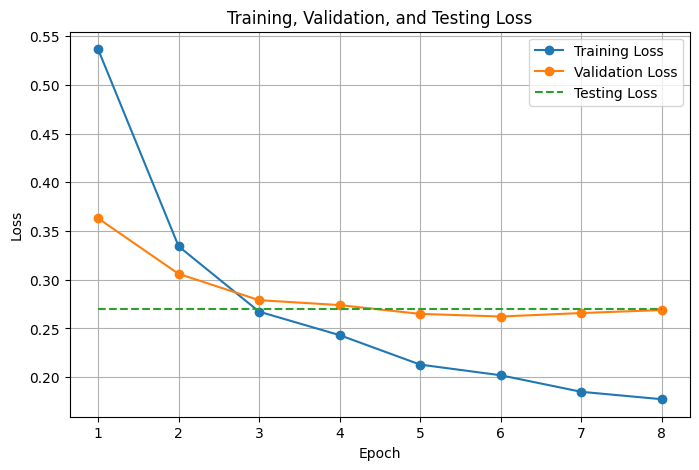

In [ ]:
test_losses = [test_loss] * len(train_losses)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, marker='o', label="Training Loss")
plt.plot(epochs_range, val_losses, marker='o', label="Validation Loss")
plt.plot(epochs_range, test_losses, linestyle='--', label="Testing Loss")
plt.title("Training, Validation, and Testing Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

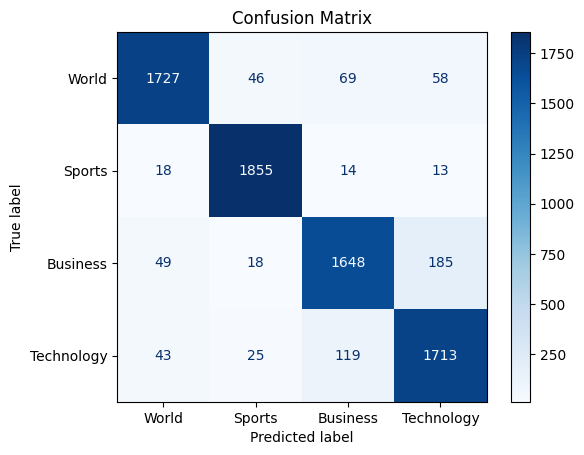

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(test_labels_list, test_predictions_list)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["World", "Sports", "Business", "Technology"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import torch.nn.functional as F
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

best_model.eval()

all_probabilities = []
all_true_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        logits = best_model(input_ids, attention_mask)
        probabilities = F.softmax(logits, dim=1)

        all_probabilities.extend(probabilities.cpu().numpy())
        all_true_labels.extend(labels.cpu().numpy())

all_probabilities = np.array(all_probabilities)
all_true_labels = np.array(all_true_labels)

In [ ]:
true_labels_binarized = label_binarize(all_true_labels, classes=[0, 1, 2, 3])

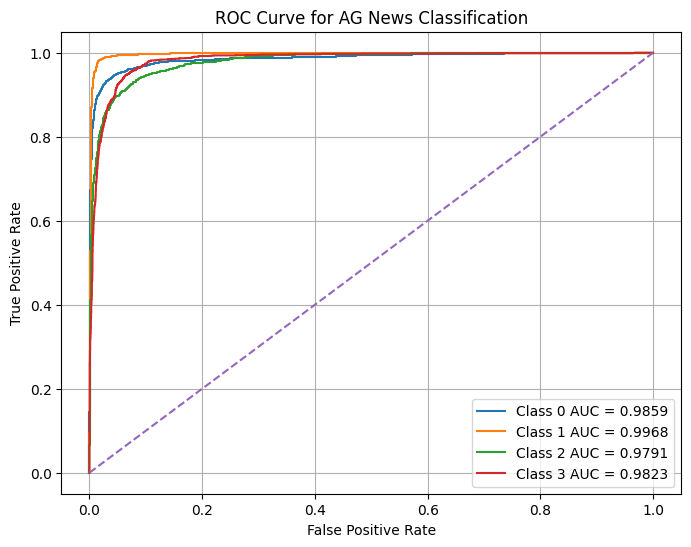

In [ ]:
plt.figure(figsize=(8, 6))

for i in range(4):
    fpr, tpr, _ = roc_curve(true_labels_binarized[:, i], all_probabilities[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} AUC = {roc_auc:.4f}")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for AG News Classification")
plt.legend()
plt.grid(True)
plt.show()

## Discussion of Results and Evaluation



*   **Learning Rate Tuning:** The learning rate of `0.001`  yielded the highest validation F1-score of `0.918` among the tested values. When re-training the final model, a learning rate of `5e-4` was chosen, which, while not the absolute best in the initial limited experiments, aimed for a more stable training process.
*   **L2 Regularization:** A `weight_decay` of `1e-5` proved the best
*   **Dropout:** Increasing the dropout rate from `0.1` to `0.2` improved the validation F1-score from `0.9124` to `0.9147`.
### Final Model Evaluation

After re-training the final model with optimized hyperparameters (dropout=0.1, lr=5e-4, weight_decay=1e-5) for 8 epochs,

*   **Final Training Loss      :** 0.1774
*   **Final Training Accuracy  :** 0.9375
*   **Final Validation Loss    :** 0.2689
*   **Final Validation Accuracy:** 0.9167
*   **Final Testing Loss       :** 0.2702
*   **Final Testing Accuracy   :** 0.9136

**Test Set Metrics:**
```
              precision    recall  f1-score   support

       World     0.9401    0.9089    0.9243      1900
      Sports     0.9542    0.9763    0.9651      1900
    Business     0.8908    0.8674    0.8789      1900
  Technology     0.8700    0.9016    0.8855      1900

    accuracy                         0.9136      7600
   macro avg     0.9138    0.9136    0.9135      7600
weighted avg     0.9138    0.9136    0.9135      7600
```


### Performance Over Epochs

1.  **Training and Validation Accuracy Over Epochs:**
    The plot shows that both training and validation accuracy steadily increased over the epochs. The training accuracy consistently remained higher than the validation accuracy, indicating a slight gap but no significant overfitting, as validation accuracy continued to improve.

2.  **Training and Validation Loss Over Epochs:**
    The plot for loss demonstrates a continuous decrease in both training and validation loss,

3.  **Training, Validation, and Testing Accuracy:**
    The plot  illustrates the progression of accuracy metrics.

4.  **Training, Validation, and Testing Loss:**
    This plot provides a comprehensive view of the loss metrics. It confirms the stability of the testing loss, indicating the model's consistent performance on new data.

### Confusion Matrix

*   The highest numbers are found along the diagonal,

### ROC Curve

*   The ROC curves for each class show a high Area Under the Curve (AUC), with values generally above `0.95`. This indicates that the model has a strong ability to distinguish between positive and negative classes for each category.



# **References:**



*   Pytorch tutorials - https://pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html

*   Matplotlib - https://matplotlib.org/stable/index.html


*   Python Docs - https://docs.python.org/3/library/time.html



*   Sci-kit learn documentation- https://scikit-learn.org/0.21/documentation.html


*   Pandas documentation- https://pandas.pydata.org/docs/


*   Dataset used - https://huggingface.co/datasets/ag_news



*   Tensorboard - https://www.tensorflow.org/tensorboard

*    Tokenizer - https://pytorch.org/text/stable/data_utils.html

*    NLTK - https://www.nltk.org/

